In [ ]:
# Install the decoders needed for JPEG Lossless DICOMs
!pip install -qU pylibjpeg pylibjpeg-libjpeg pydicom python-gdcm

## Import Required Libraries
We import all necessary libraries for data handling, visualization, and analysis.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

2026-03-26 16:40:01.926296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774543202.120869     107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774543202.175438     107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774543202.608935     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774543202.608999     107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774543202.609002     107 computation_placer.cc:177] computation placer alr

Libraries imported successfully!


## Load Dataset
Load training and testing datasets from the Kaggle input directory.

In [2]:
BASE_PATH = "/kaggle/input/competitions/rsna-breast-cancer-detection"

train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
test_df = pd.read_csv(f"{BASE_PATH}/test.csv")

print("Data loaded successfully!")
print(f"Training Shape: {train_df.shape}")
print(f"Testing Shape: {test_df.shape}")

Data loaded successfully!
Training Shape: (54706, 14)
Testing Shape: (4, 9)


## Preview Dataset
Display first few rows to understand structure and features.

In [3]:
train_df.head()

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


## Dataset Information
Check data types, non-null values, and memory usage.

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54706 entries, 0 to 54705
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   site_id                  54706 non-null  int64  
 1   patient_id               54706 non-null  int64  
 2   image_id                 54706 non-null  int64  
 3   laterality               54706 non-null  object 
 4   view                     54706 non-null  object 
 5   age                      54669 non-null  float64
 6   cancer                   54706 non-null  int64  
 7   biopsy                   54706 non-null  int64  
 8   invasive                 54706 non-null  int64  
 9   BIRADS                   26286 non-null  float64
 10  implant                  54706 non-null  int64  
 11  density                  29470 non-null  object 
 12  machine_id               54706 non-null  int64  
 13  difficult_negative_case  54706 non-null  bool   
dtypes: bool(1), float64(2)

## Statistical Summary
Get numerical insights like mean, std, min, max.

In [5]:
train_df.describe()

,site_id,patient_id,image_id,age,cancer,biopsy,invasive,BIRADS,implant,machine_id
count,54706.000000,54706.000000,5.470600e+04,54669.000000,54706.000000,54706.000000,54706.000000,26286.000000,54706.000000,54706.000000
mean,1.460407,32698.865262,1.079386e+09,58.543928,0.021168,0.054272,0.014953,0.772350,0.026999,54.618378
std,0.498434,18893.861534,6.183269e+08,10.050884,0.143944,0.226556,0.121365,0.590062,0.162081,44.784800
min,1.000000,5.000000,6.849100e+04,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000
25%,1.000000,16481.000000,5.458153e+08,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000
50%,1.000000,32432.000000,1.082689e+09,59.000000,0.000000,0.000000,0.000000,1.000000,0.000000,49.000000
75%,2.000000,48999.000000,1.613228e+09,66.000000,0.000000,0.000000,0.000000,1.000000,0.000000,49.000000
max,2.000000,65534.000000,2.147472e+09,89.000000,1.000000,1.000000,1.000000,2.000000,1.000000,216.000000


## Target Variable Distribution
Analyze the distribution of cancer vs non-cancer cases.

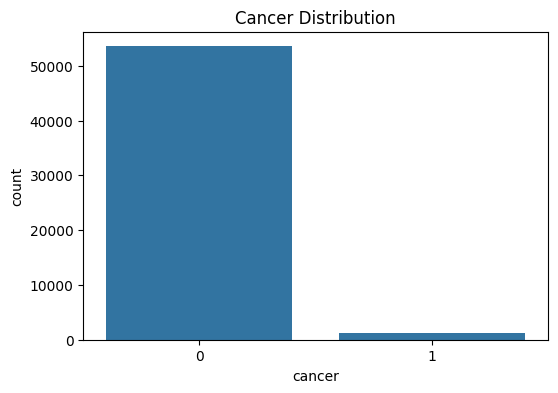

cancer
0    0.978832
1    0.021168
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='cancer')
plt.title("Cancer Distribution")
plt.show()

print(train_df['cancer'].value_counts(normalize=True))

## Age Distribution
Visualize distribution of patient ages.

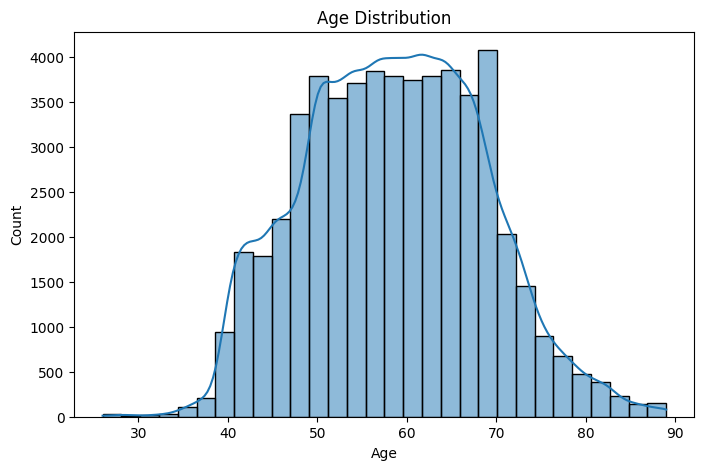

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## Laterality (Left/Right Breast)
Check distribution of left vs right breast images.

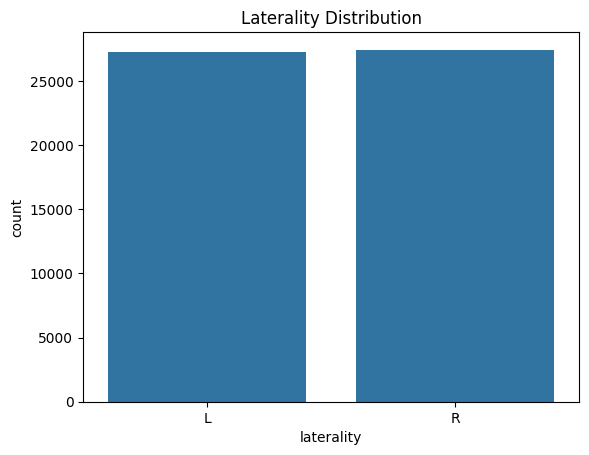

In [9]:
sns.countplot(data=train_df, x='laterality')
plt.title("Laterality Distribution")
plt.show()

## Cancer vs Age
Compare age distribution for cancer and non-cancer patients.

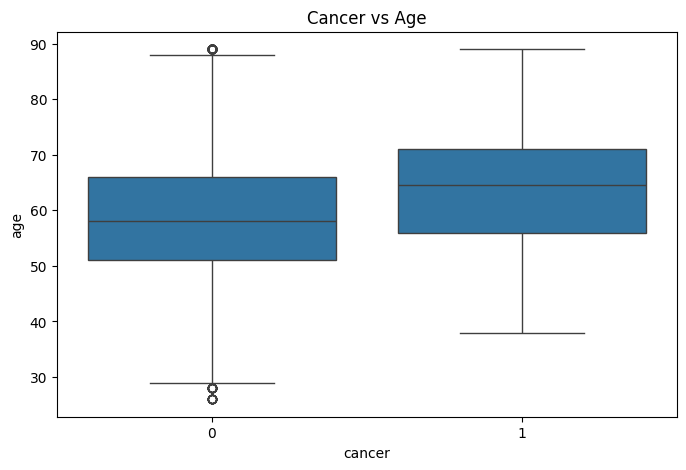

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='cancer', y='age', data=train_df)
plt.title("Cancer vs Age")
plt.show()

## Implant vs Cancer
Check whether implants affect cancer distribution.

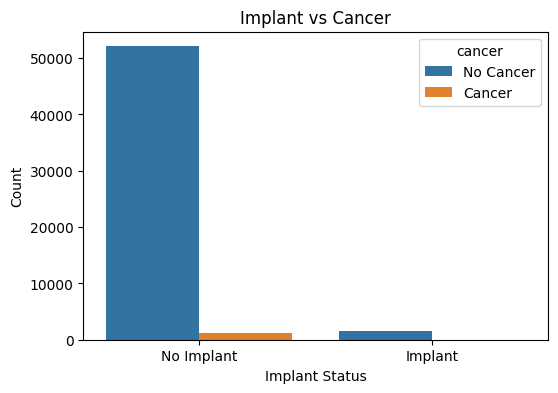

In [11]:
# Create a copy to avoid modifying original data
df_plot = train_df.copy()

# Map values to labels
df_plot['implant'] = df_plot['implant'].map({0: 'No Implant', 1: 'Implant'})
df_plot['cancer'] = df_plot['cancer'].map({0: 'No Cancer', 1: 'Cancer'})

# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_plot, x='implant', hue='cancer')

plt.title("Implant vs Cancer")
plt.xlabel("Implant Status")
plt.ylabel("Count")

plt.show()

## Display a Single Image
Load and visualize one DICOM image using patient_id and image_id.

In [12]:
BASE_PATH = "/kaggle/input/competitions/rsna-breast-cancer-detection"
TRAIN_IMG_PATH = f"{BASE_PATH}/train_images"

Image Path: /kaggle/input/competitions/rsna-breast-cancer-detection/train_images/10006/462822612.dcm


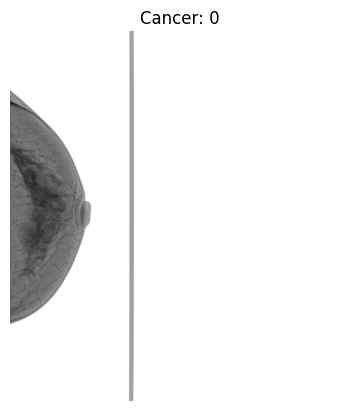

In [13]:
# Select sample
row = train_df.iloc[0]

patient_id = str(row['patient_id'])
image_id = str(row['image_id'])

# Correct file path
img_path = os.path.join(TRAIN_IMG_PATH, patient_id, f"{image_id}.dcm")

print("Image Path:", img_path)

# Read and display
dicom = pydicom.dcmread(img_path)
image = dicom.pixel_array

plt.imshow(image, cmap='gray')
plt.title(f"Cancer: {row['cancer']}")
plt.axis('off')
plt.show()

## Display Multiple Images
Show random images from dataset.

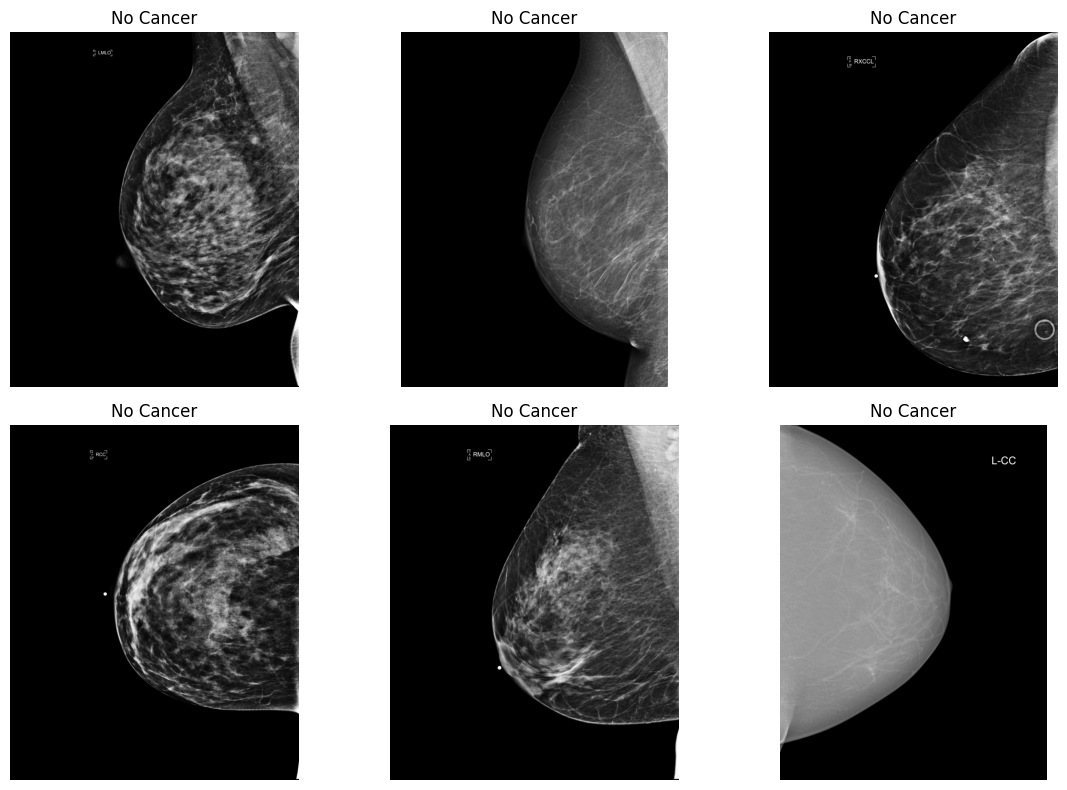

In [14]:
samples = train_df.sample(6)

plt.figure(figsize=(12,8))

for i, (_, row) in enumerate(samples.iterrows()):
    patient_id = str(row['patient_id'])
    image_id = str(row['image_id'])
    
    img_path = os.path.join(TRAIN_IMG_PATH, patient_id, f"{image_id}.dcm")
    
    dicom = pydicom.dcmread(img_path)
    image = dicom.pixel_array
    
    plt.subplot(2, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title("Cancer" if row['cancer']==1 else "No Cancer")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Handle Class Imbalance (Undersampling)

In [15]:
# Separate classes
df_0 = train_df[train_df['cancer'] == 0]
df_1 = train_df[train_df['cancer'] == 1]

# Undersample majority class
df_0_under = df_0.sample(len(df_1), random_state=42)

# Combine
df_balanced = pd.concat([df_0_under, df_1]).sample(frac=1)

print(df_balanced['cancer'].value_counts())

cancer
0    1158
1    1158
Name: count, dtype: int64


In [16]:
train_data, test_data = train_test_split(
    df_balanced, test_size=0.2, stratify=df_balanced['cancer'], random_state=42
)

## Image Preprocessing (Resize + Normalize)

In [18]:
IMG_SIZE = 224

def load_image(row):
    try:
        patient_id = str(int(row['patient_id']))
        image_id = str(int(row['image_id']))
        
        path = os.path.join(TRAIN_IMG_PATH, patient_id, f"{image_id}.dcm")
        
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array
        
        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # Normalize
        img = img / 255.0
        
        # Convert to 3 channel
        img = np.stack((img,)*3, axis=-1)
        
        return img
    except:
        return None

## Load Images into RAM

In [19]:
def load_dataset(df):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        img = load_image(row)
        if img is not None:
            images.append(img)
            labels.append(row['cancer'])
    
    return np.array(images), np.array(labels)

X_train, y_train = load_dataset(train_data)
X_test, y_test = load_dataset(test_data)

print(X_train.shape, X_test.shape)

(1852, 224, 224, 3) (464, 224, 224, 3)


## Model 1 (Simple CNN)

In [21]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.4950 - loss: 11.0613 - val_accuracy: 0.5259 - val_loss: 0.6917
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6978 - loss: 0.6114 - val_accuracy: 0.5431 - val_loss: 0.7387
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8033 - loss: 0.4256 - val_accuracy: 0.5582 - val_loss: 0.8745
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8767 - loss: 0.2663 - val_accuracy: 0.5517 - val_loss: 1.1649
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9093 - loss: 0.1798 - val_accuracy: 0.5539 - val_loss: 1.5354


## Model 2 (ResNet50)

In [22]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base.input, outputs=output)
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

resnet_model = build_resnet()

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 122s 999ms/step - accuracy: 0.5257 - loss: 0.9008 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 326ms/step - accuracy: 0.5697 - loss: 0.6789 - val_accuracy: 0.5000 - val_loss: 4.3233
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 347ms/step - accuracy: 0.5247 - loss: 0.6775 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 353ms/step - accuracy: 0.5474 - loss: 0.6882 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 338ms/step - accuracy: 0.5698 - loss: 0.6880 - val_accuracy: 0.5733 - val_loss: 0.7421


## Model 3 (EfficientNetB0)

In [23]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base.input, outputs=output)
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

eff_model = build_efficientnet()

history_eff = eff_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


2026-03-26 17:16:07.012723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:16:07.156683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:16:07.525857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:16:07.668028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:16:07.810206: E external/local_xla/xla/stream_

57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5169 - loss: 0.7227

2026-03-26 17:17:07.285348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:07.427372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:07.782101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:07.924309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:08.739912: E external/local_xla/xla/stream_

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5173 - loss: 0.7225   

2026-03-26 17:17:59.205283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:59.345277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:59.677845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:17:59.819673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:18:00.599537: E external/local_xla/xla/stream_

58/58 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.5176 - loss: 0.7222 - val_accuracy: 0.5000 - val_loss: 0.8875
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.5807 - loss: 0.6755 - val_accuracy: 0.5496 - val_loss: 0.6904
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5688 - loss: 0.6672 - val_accuracy: 0.5517 - val_loss: 0.6987
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.6295 - loss: 0.6403 - val_accuracy: 0.5496 - val_loss: 0.6881
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.6488 - loss: 0.6150 - val_accuracy: 0.5690 - val_loss: 0.7308


## Evaluation Function

In [28]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test):
    # Get probability scores for ROC curve
    y_probs = model.predict(X_test).ravel()
    # Convert probabilities to binary predictions
    y_pred = (y_probs > 0.5).astype("int32")
    
    # 1. Print Standard Metrics
    print("--- Model Performance Metrics ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    
    # 2. ROC-AUC Score
    roc_auc = roc_auc_score(y_test, y_probs)
    print(f"ROC AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # 3. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title("Confusion Matrix")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('Receiver Operating Characteristic (ROC)')
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

CNN Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
--- Model Performance Metrics ---
Accuracy:  0.5539
Precision: 0.5616
Recall:    0.4914
F1 Score:  0.5241
ROC AUC:   0.5684

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.62      0.58       232
           1       0.56      0.49      0.52       232

    accuracy                           0.55       464
   macro avg       0.55      0.55      0.55       464
weighted avg       0.55      0.55      0.55       464



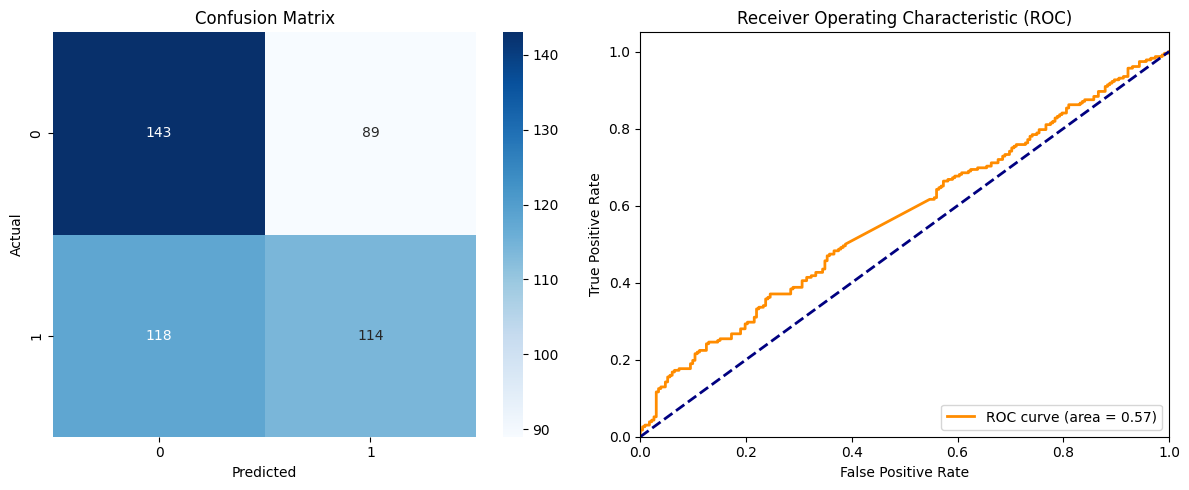

ResNet Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
--- Model Performance Metrics ---
Accuracy:  0.5733
Precision: 0.5752
Recall:    0.5603
F1 Score:  0.5677
ROC AUC:   0.5978

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.59      0.58       232
           1       0.58      0.56      0.57       232

    accuracy                           0.57       464
   macro avg       0.57      0.57      0.57       464
weighted avg       0.57      0.57      0.57       464



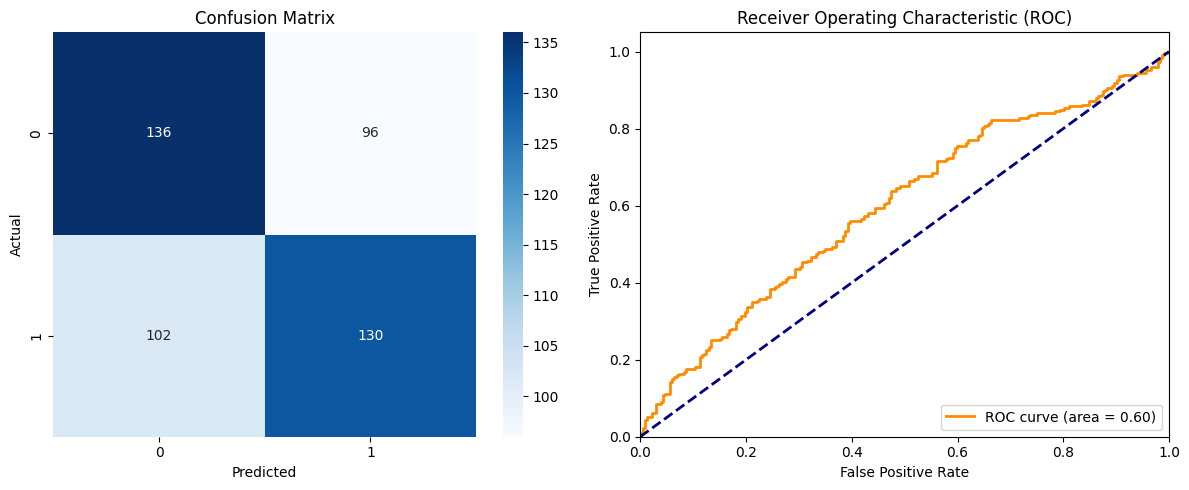

EfficientNet Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
--- Model Performance Metrics ---
Accuracy:  0.5690
Precision: 0.5635
Recall:    0.6121
F1 Score:  0.5868
ROC AUC:   0.5824

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.53      0.55       232
           1       0.56      0.61      0.59       232

    accuracy                           0.57       464
   macro avg       0.57      0.57      0.57       464
weighted avg       0.57      0.57      0.57       464



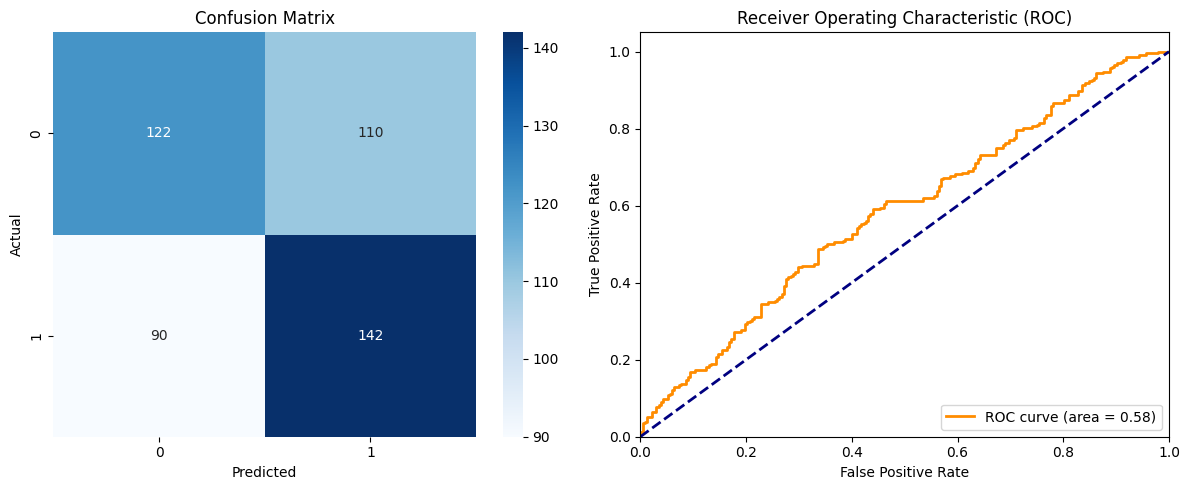

In [29]:
print("CNN Model:")
evaluate_model(cnn_model, X_test, y_test)

print("ResNet Model:")
evaluate_model(resnet_model, X_test, y_test)

print("EfficientNet Model:")
evaluate_model(eff_model, X_test, y_test)

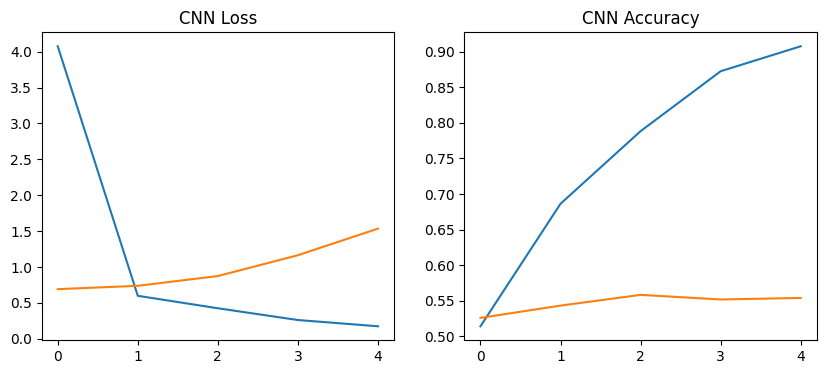

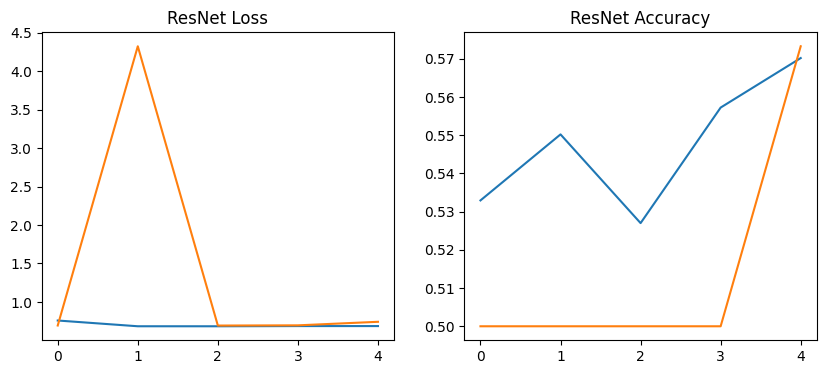

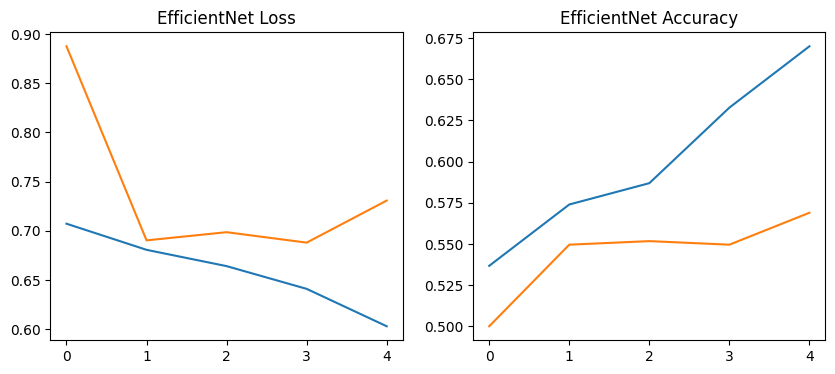

In [27]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))
    
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f"{title} Loss")
    
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f"{title} Accuracy")
    
    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_resnet, "ResNet")
plot_history(history_eff, "EfficientNet")

## Data Augmentation (Prevents Overfitting)

In [30]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

## Improved CNN with Regularization

In [32]:
def build_improved_cnn():
    inputs = layers.Input(shape=(224,224,3))
    
    x = data_augmentation(inputs)
    
    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)   # ✅ FIXED
    
    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)   # ✅ FIXED
    
    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)   # ✅ FIXED
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    return model

In [35]:
model = build_improved_cnn()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [33]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0)}


In [37]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.5642 - loss: 0.6760 - precision: 0.5566 - recall: 0.7219 - val_accuracy: 0.5431 - val_loss: 0.6998 - val_precision: 0.5258 - val_recall: 0.8793
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5474 - loss: 0.6819 - precision: 0.5383 - recall: 0.5287 - val_accuracy: 0.5560 - val_loss: 0.7181 - val_precision: 0.5346 - val_recall: 0.8664
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5461 - loss: 0.6823 - precision: 0.5371 - recall: 0.6152 - val_accuracy: 0.5409 - val_loss: 0.7152 - val_precision: 0.5241 - val_recall: 0.8922
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5561 - loss: 0.6821 - precision: 0.5528 - recall: 0.6789 - val_accuracy: 0.5453 - val_loss: 0.7049 - val_precision: 0.5266 - val_recall: 0.8966
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5608 - loss: 0.6810 - precision: 0.5658 - recall: 0.5371 - val_accuracy: 0.5431 - val_loss: 0.

CNN Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
--- Model Performance Metrics ---
Accuracy:  0.5603
Precision: 0.5389
Recall:    0.8362
F1 Score:  0.6554
ROC AUC:   0.6222

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.28      0.39       232
           1       0.54      0.84      0.66       232

    accuracy                           0.56       464
   macro avg       0.59      0.56      0.52       464
weighted avg       0.59      0.56      0.52       464



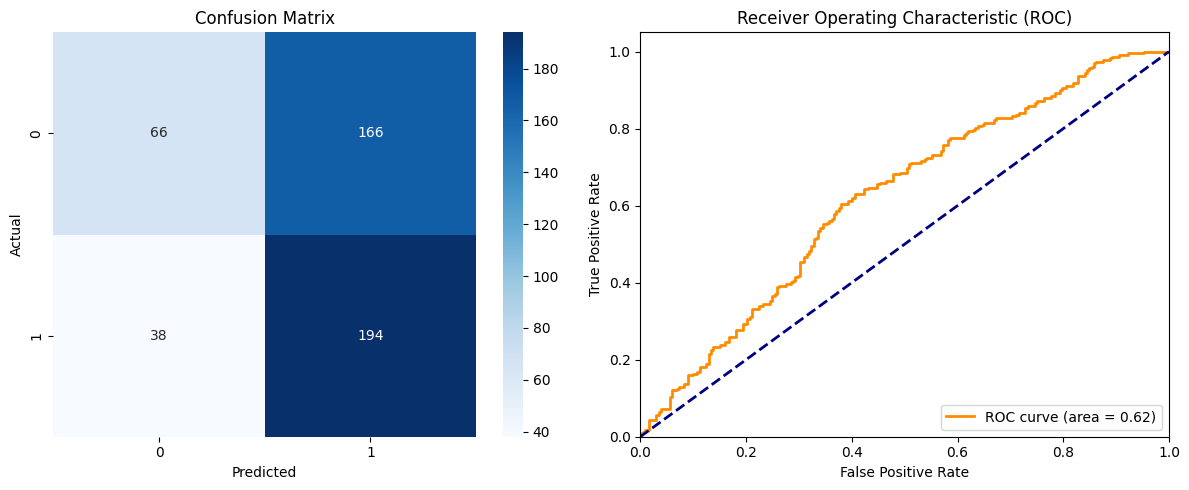

In [41]:
print("CNN Model:")
evaluate_model(model, X_test, y_test)

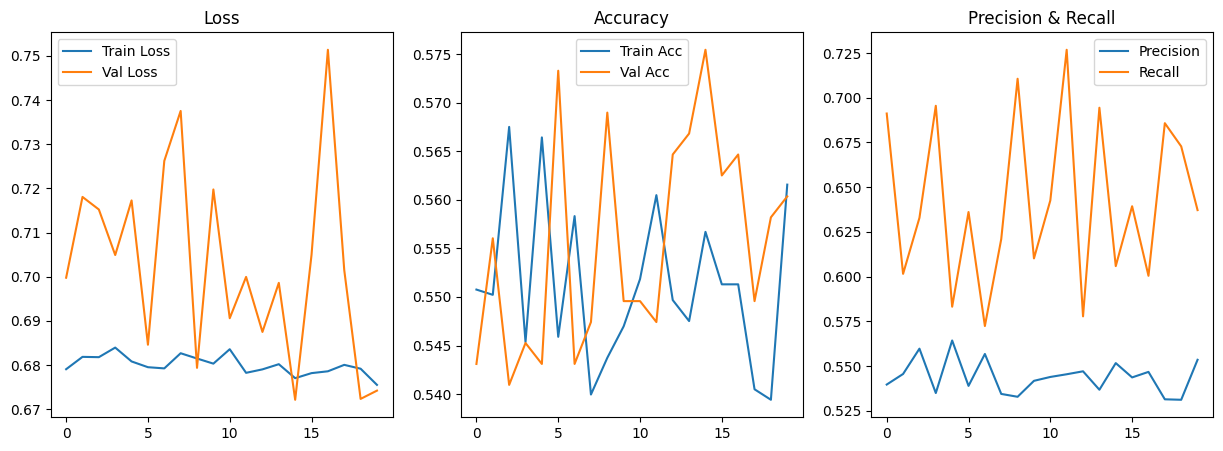

In [40]:
def plot_history(history):
    plt.figure(figsize=(15,5))
    
    # Loss
    plt.subplot(1,3,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.legend()
    
    # Accuracy
    plt.subplot(1,3,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy")
    plt.legend()
    
    # Precision & Recall
    plt.subplot(1,3,3)
    plt.plot(history.history['precision'], label='Precision')
    plt.plot(history.history['recall'], label='Recall')
    plt.title("Precision & Recall")
    plt.legend()
    
    plt.show()

plot_history(history)

## EfficientNet Model (Transfer Learning)

In [42]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base.trainable = False  # Freeze base
    
    inputs = layers.Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

In [43]:
eff_model = build_efficientnet()

history_eff = eff_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
)

Epoch 1/15


E0000 00:00:1774548268.465699     107 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_6_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 187ms/step - accuracy: 0.4891 - loss: 0.9017 - precision: 0.4885 - recall: 0.4983 - val_accuracy: 0.5409 - val_loss: 0.6868 - val_precision: 0.5613 - val_recall: 0.3750
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5313 - loss: 0.8194 - precision: 0.5343 - recall: 0.5531 - val_accuracy: 0.5560 - val_loss: 0.6883 - val_precision: 0.5747 - val_recall: 0.4310
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5523 - loss: 0.7911 - precision: 0.5584 - recall: 0.5563 - val_accuracy: 0.5668 - val_loss: 0.6887 - val_precision: 0.5876 - val_recall: 0.4483
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.5447 - loss: 0.7897 - precision: 0.5562 - recall: 0.5275 - val_accuracy: 0.5668 - val_loss: 0.6896 - val_precision: 0.5742 - val_recall: 0.5172
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5459 - loss: 0.7747 - precision: 0.5457 - recall: 0.5585 - val_accuracy: 0.5582 - val_loss: 0.6870 - val

Efficientnet Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
--- Model Performance Metrics ---
Accuracy:  0.5754
Precision: 0.5862
Recall:    0.5129
F1 Score:  0.5471
ROC AUC:   0.5858

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60       232
           1       0.59      0.51      0.55       232

    accuracy                           0.58       464
   macro avg       0.58      0.58      0.57       464
weighted avg       0.58      0.58      0.57       464



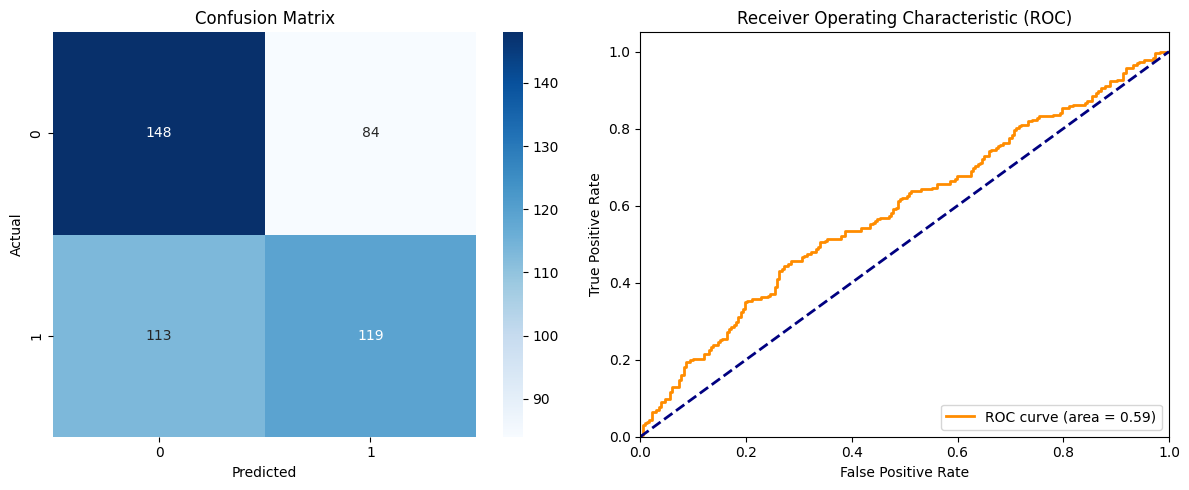

In [45]:
print("Efficientnet Model:")
evaluate_model(eff_model, X_test, y_test)

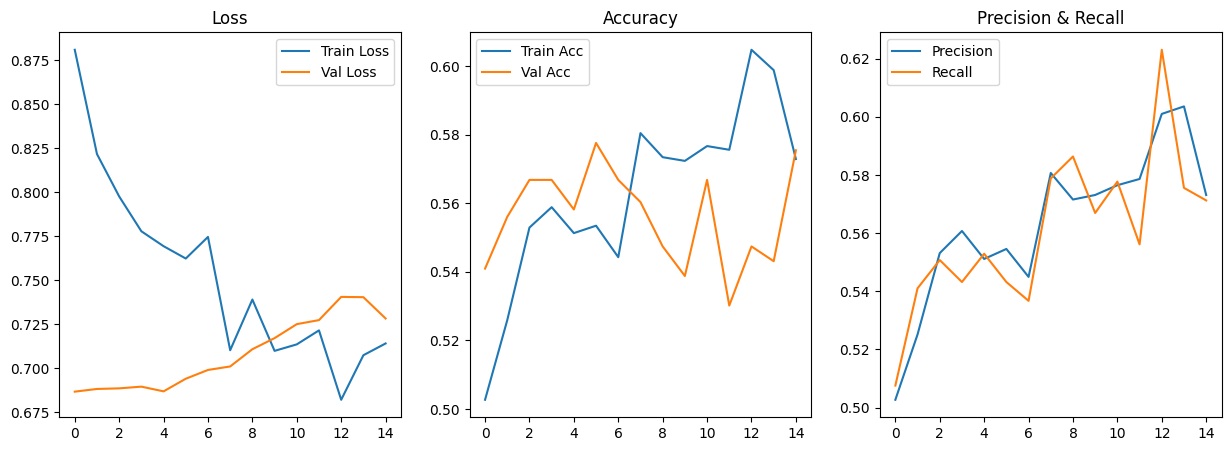

In [46]:
plot_history(history_eff)

## ResNet50 Model (Transfer Learning)

In [47]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base.trainable = False
    
    inputs = layers.Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

In [49]:
resnet_model = build_resnet()

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.5245 - loss: 0.9170 - precision: 0.5366 - recall: 0.5870 - val_accuracy: 0.5453 - val_loss: 0.6912 - val_precision: 0.5439 - val_recall: 0.5603
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.5176 - loss: 0.8777 - precision: 0.5283 - recall: 0.5193 - val_accuracy: 0.5517 - val_loss: 0.6882 - val_precision: 0.5556 - val_recall: 0.5172
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.5659 - loss: 0.7824 - precision: 0.5801 - recall: 0.5643 - val_accuracy: 0.5366 - val_loss: 0.6877 - val_precision: 0.5333 - val_recall: 0.5862
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.5622 - loss: 0.8048 - precision: 0.5780 - recall: 0.5796 - val_accuracy: 0.5453 - val_loss: 0.6836 - val_precision: 0.5429 - val_recall: 0.5733
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.5802 - loss: 0.7442 - precision: 0.5731 - recall: 0.5871 - val_accuracy: 0.5496 - val_los

Resnet Model:
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step
--- Model Performance Metrics ---
Accuracy:  0.5905
Precision: 0.5789
Recall:    0.6638
F1 Score:  0.6185
ROC AUC:   0.6428

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.52      0.56       232
           1       0.58      0.66      0.62       232

    accuracy                           0.59       464
   macro avg       0.59      0.59      0.59       464
weighted avg       0.59      0.59      0.59       464



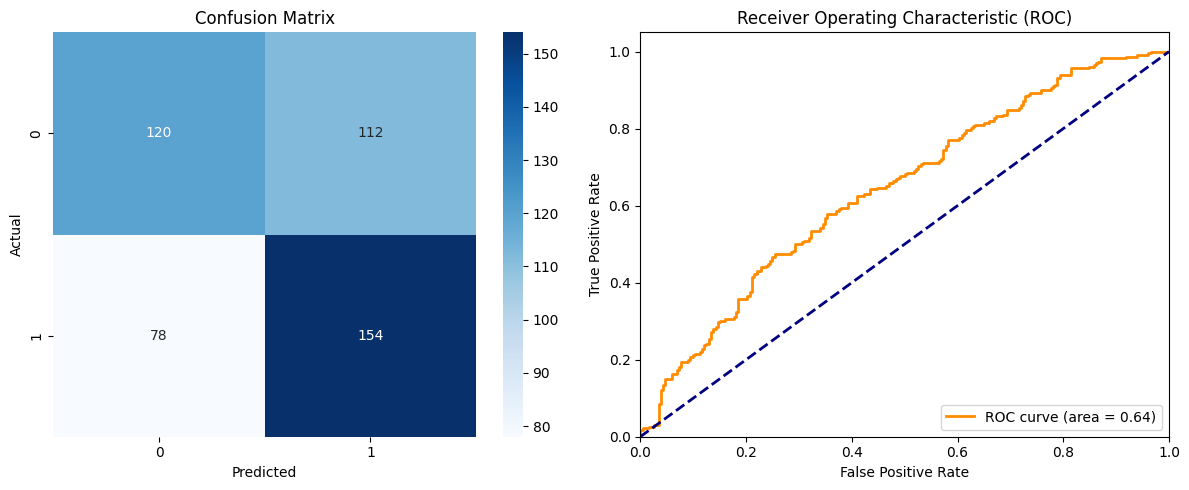

In [50]:
print("Resnet Model:")
evaluate_model(resnet_model, X_test, y_test)

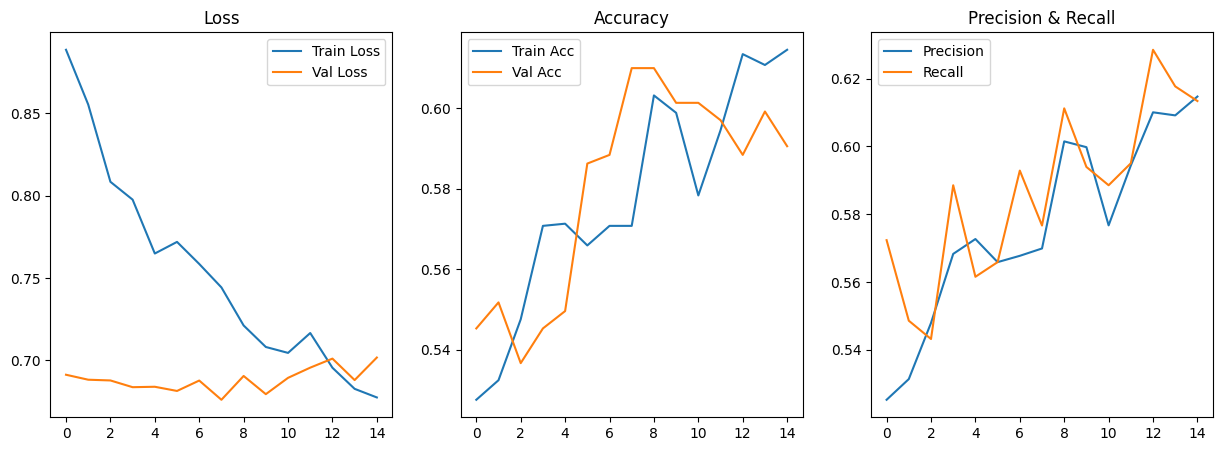

In [51]:
plot_history(history_resnet)